# GalaxIA — Día 3: comparación rigurosa e interpretabilidad

El resumen afirma que las redes neuronales *"alcanzaron niveles superiores"*.
Dos números distintos no bastan para sostener eso: hace falta una prueba
estadística. Aquí se cierra ese punto y se genera el material visual.

Resultados del día 2 (F1-macro): CNN 0.9456 · MLP-PCA 0.8535 ·
MLP-Params 0.8515 · MLP-Fusion 0.8509 · SVM 0.8357 · KNN 0.7909.

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from galaxia import data, labels, evaluate, explain
data.fijar_semillas(42)

display(evaluate.tabla_comparativa())

2026-08-26 22:26:08.790668: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787801168.801451  103792 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787801168.804642  103792 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1787801168.813427  103792 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787801168.813437  103792 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787801168.813438  103792 computation_placer.cc:177] computation placer alr

,Modelo,Accuracy,F1-macro,AUC-ROC,AP-macro,t entren. (s),t infer. (s)
6,CNN 128px,0.9624,0.9456,0.9926,0.9793,795.7611,2.2457
8,MLP-PCA,0.8790,0.8535,0.9647,0.9267,9.0300,0.4532
9,MLP-Params,0.8770,0.8515,0.9634,0.9246,11.8053,0.4169
10,MLP-Fusion,0.8773,0.8509,0.9606,0.9200,6.7407,0.4286
3,SVM (RBF),0.8616,0.8357,0.9505,0.9036,93.8466,3.1435
1,SVM (RGB + recorte),0.8616,0.8357,0.9505,0.9036,95.0447,2.8612
0,"SVM (gris, sin recorte)",0.8323,0.8112,0.9305,0.8737,51.1044,1.9567
7,KNN,0.8092,0.7909,0.9285,0.8756,39.8553,0.1851
2,Regresión logística,0.7218,0.6823,0.8488,0.7128,90.3838,0.2348
5,SGD (log-loss),0.7175,0.6685,0.7969,0.6189,64.8105,0.4100


## 1. ¿Las diferencias son reales? Prueba de McNemar

McNemar compara dos modelos sobre **las mismas** muestras: cuenta en cuántos
casos uno acierta y el otro falla. Es la prueba adecuada cuando ambos modelos se
evalúan sobre el mismo conjunto de prueba.

In [2]:
preds = {}
for f in sorted(evaluate.DIR_REP.glob("pred_*.npz")):
    z = np.load(f)
    preds[f.stem.replace("pred_", "")] = {"y": z["y_true"], "p": z["y_pred"]}
print("Predicciones guardadas:", list(preds))

Predicciones guardadas: ['cnn_128px', 'knn', 'mlp_fusion', 'mlp_params', 'mlp_pca']


In [3]:
# Comparaciones que importan para la ponencia
pares = [
    ("cnn_128px", "mlp_pca",     "CNN vs MLP-PCA"),
    ("cnn_128px", "mlp_params",  "CNN vs MLP-Params"),
    ("mlp_pca",   "mlp_params",  "MLP-PCA vs MLP-Params"),
    ("mlp_fusion","mlp_pca",     "Fusión vs solo PCA"),
    ("mlp_pca",   "knn",         "MLP-PCA vs KNN"),
]

filas = []
for a, b, etiqueta in pares:
    if a not in preds or b not in preds:
        print(f"(falta {a} o {b})"); continue
    r = evaluate.mcnemar_modelos(preds[a]["y"], preds[a]["p"], preds[b]["p"], a, b)
    filas.append({"Comparación": etiqueta,
                  "solo A acierta": r["tabla"][0][1],
                  "solo B acierta": r["tabla"][1][0],
                  "chi2": round(r["statistic"], 2),
                  "p-valor": r["pvalue"],
                  "¿significativo?": "sí" if r["significativo_0.05"] else "no"})

tab_mc = pd.DataFrame(filas)
display(tab_mc.style.format({"p-valor": "{:.2e}"}))
json.dump(filas, open(evaluate.DIR_REP / "mcnemar.json", "w"), indent=2, default=str)

,Comparación,solo A acierta,solo B acierta,chi2,p-valor,¿significativo?
0,CNN vs MLP-PCA,328,35,234.890000,5.12e-53,sí
1,CNN vs MLP-Params,344,44,230.410000,4.84e-52,sí
2,MLP-PCA vs MLP-Params,180,173,0.100000,7.49e-01,no
3,Fusión vs solo PCA,83,89,0.150000,7.03e-01,no
4,MLP-PCA vs KNN,370,125,120.270000,5.51e-28,sí


**Cómo leerlo.** Si `p < 0.05`, la diferencia no se explica por azar. Si
`MLP-PCA vs MLP-Params` sale **no significativo**, ese es el resultado más
interesante del trabajo: 24 parámetros interpretables igualan a cientos de
componentes principales opacas. Y si `Fusión vs solo PCA` tampoco es
significativo, confirma que ambas representaciones codifican lo mismo.

## 2. Interpretabilidad de la CNN — Grad-CAM

Un F1-macro de 0.95 no prueba por sí solo que la red aprendió morfología: podría
estar explotando un artefacto del conjunto de datos. Grad-CAM lo verifica.

In [4]:
import keras
ruta_cnn = data.RAIZ / "models" / "cnn_128.keras"
cnn = keras.models.load_model(ruta_cnn)

df = labels.construir_etiquetas(data.cargar_csv())
p = data.DIR_PROC / "umbral.json"
UMBRAL = json.loads(p.read_text())["umbral"] if p.exists() else 0.6
df_clean = labels.filtrar_por_confianza(df, umbral=UMBRAL)
d = data.preparar_conjunto(df_clean, size=128)
clases = d["clases"]
Xte = np.array(d["test"]["X"]); yte = d["test"]["y"]
print(clases, Xte.shape)

I0000 00:00:1787801170.116380  103792 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1096 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:07:00.0, compute capability: 8.9
/home/sergio/Documentos/Entornos/GalIA/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 62 variables whereas the saved optimizer has 66 variables. 
  saveable.load_own_variables(store)


['Disk', 'Smooth', 'Spiral'] (3512, 128, 128, 3)


conv2d                       128x128
conv2d_1                     128x128
conv2d_2                     64x64
conv2d_3                     64x64
conv2d_4                     32x32
conv2d_5                     32x32
conv2d_6                     16x16
conv2d_7                     16x16
ultima_conv                  8x8


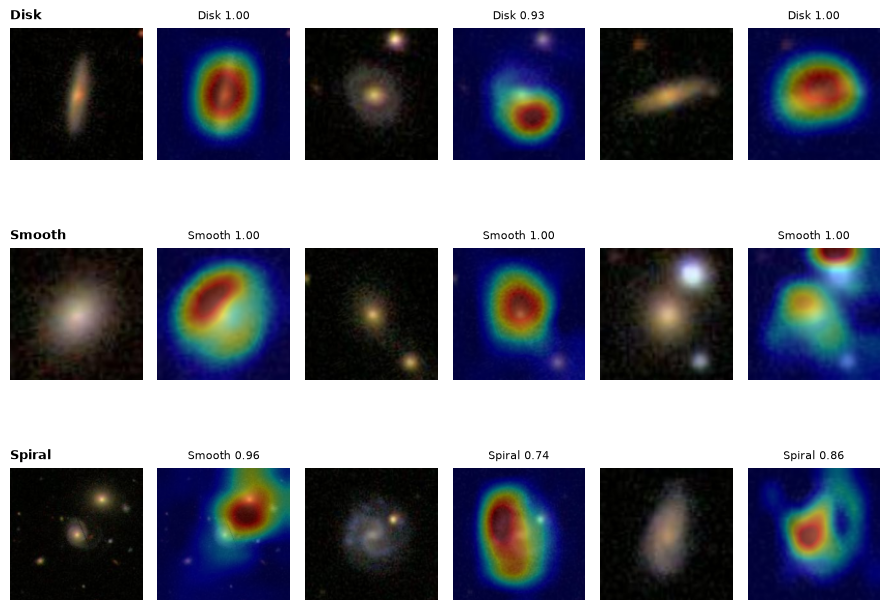

In [9]:
#fig = explain.rejilla_gradcam(cnn, Xte, yte, clases, n_por_clase=3,
 #                             ruta_salida=str(evaluate.DIR_FIG / "gradcam.png"))
#plt.show()


# Ver qué capas hay disponibles y su resolución espacial
for capa in cnn.layers:
    s = capa.output.shape
    if len(s) == 4 and "conv" in capa.name.lower():
        print(f"{capa.name:28s} {s[1]}x{s[2]}")

# Usar una de 16x16 para el doble de detalle
fig = explain.rejilla_gradcam(cnn, Xte, yte, clases, n_por_clase=3,
                              ruta_salida=str(evaluate.DIR_FIG / "gradcam_fino.png"))
# ...o directamente: explain.grad_cam(cnn, img, capa="NOMBRE_DE_LA_CAPA_16x16")

**Qué buscar.** Las zonas cálidas deben caer sobre el bulbo y los brazos. Si
aparecen en las esquinas o en el fondo, la red está usando algo que no es
morfología y hay que decirlo. Es una comprobación de honestidad científica, no
un adorno.

## 3. Análisis de errores

La figura más importante de la ponencia: exactitud frente al consenso humano.

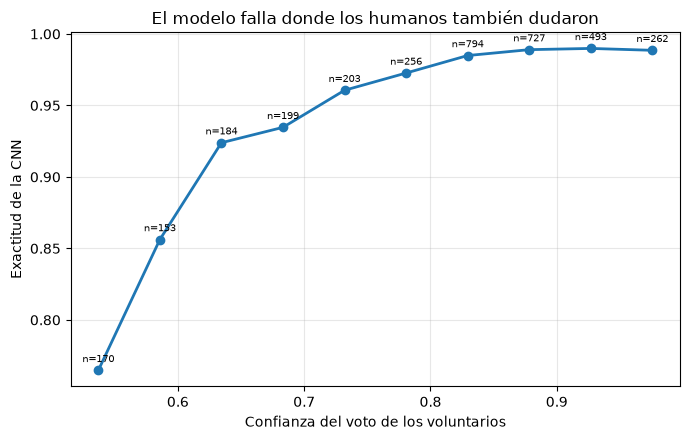

In [6]:
conf_test = d["test"]["confianza"]
pred_cnn = preds["cnn_128px"]["p"] if "cnn_128px" in preds else None

if pred_cnn is not None:
    r = evaluate.accuracy_vs_confianza(yte, pred_cnn, conf_test, bins=10, nombre="CNN")
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(r["centros"], r["accuracy"], "o-", lw=2)
    for x, y, n in zip(r["centros"], r["accuracy"], r["n"]):
        ax.annotate(f"n={n}", (x, y), fontsize=7, xytext=(0, 6),
                    textcoords="offset points", ha="center")
    ax.set_xlabel("Confianza del voto de los voluntarios")
    ax.set_ylabel("Exactitud de la CNN"); ax.grid(alpha=.3)
    ax.set_title("El modelo falla donde los humanos también dudaron")
    plt.tight_layout(); plt.savefig(evaluate.DIR_FIG / "conf_vs_acc.png", dpi=150)
    plt.show()

In [7]:
# Galería de errores: dónde se confunde exactamente
errores = np.where(pred_cnn != yte)[0]
print(f"{len(errores)} errores de {len(yte)} ({len(errores)/len(yte)*100:.1f} %)")

from collections import Counter
conf_pares = Counter((clases[yte[i]], clases[pred_cnn[i]]) for i in errores)
for (real, pred), n in conf_pares.most_common():
    print(f"  {real:8s} -> {pred:8s} : {n}")

132 errores de 3512 (3.8 %)
  Disk     -> Spiral   : 74
  Spiral   -> Disk     : 22
  Smooth   -> Spiral   : 12
  Spiral   -> Smooth   : 11
  Smooth   -> Disk     : 10
  Disk     -> Smooth   : 3


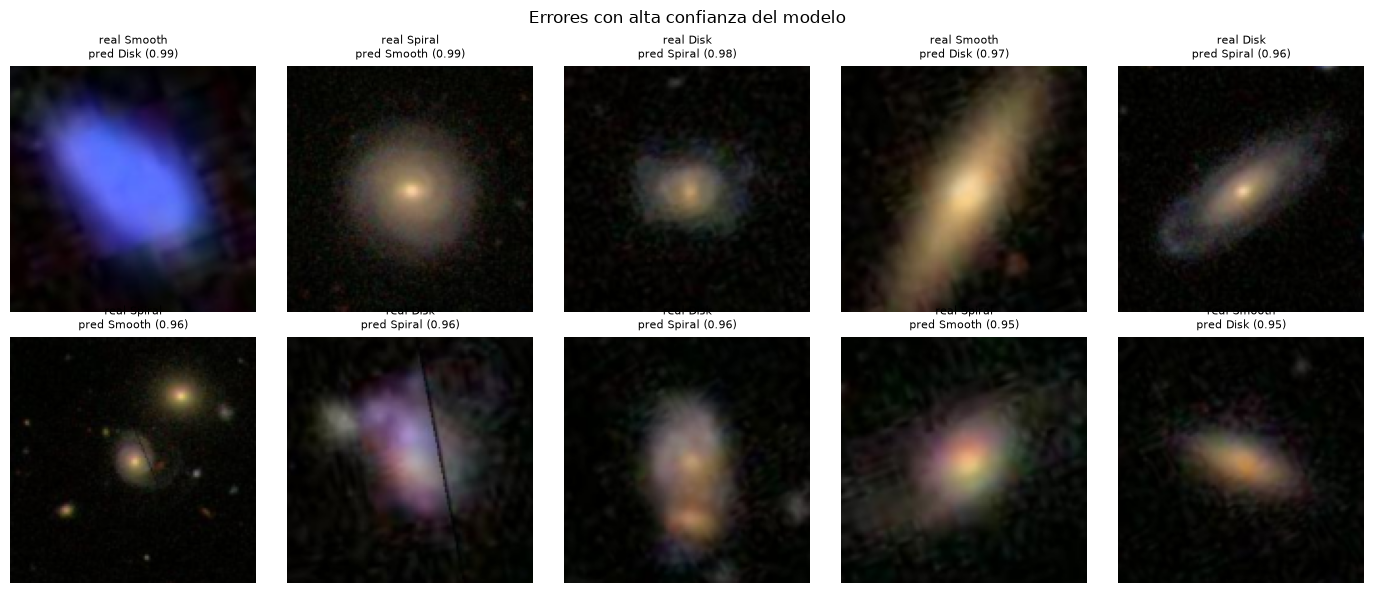

In [8]:
# Los errores más "seguros": donde el modelo se equivocó con alta confianza
z = np.load(evaluate.DIR_REP / "pred_cnn_128px.npz")
proba = z["proba"]
seguridad = proba.max(1)
peores = errores[np.argsort(-seguridad[errores])][:10]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for a, i in zip(axes.ravel(), peores):
    a.imshow(Xte[i]); a.axis("off")
    a.set_title(f"real {clases[yte[i]]}\npred {clases[pred_cnn[i]]} "
                f"({seguridad[i]:.2f})", fontsize=8)
fig.suptitle("Errores con alta confianza del modelo")
plt.tight_layout(); plt.savefig(evaluate.DIR_FIG / "errores.png", dpi=140); plt.show()

Revisen estas diez a ojo. En muchos casos van a encontrar que la etiqueta de
Galaxy Zoo es discutible y el modelo no está tan equivocado. Eso es material
directo para la discusión de la ponencia.

## 4. Exportar artefactos para la interfaz

Desde terminal:

```bash
python scripts/export_artefactos.py
streamlit run app/Inicio.py
```

## 5. Cierre del día 3

- [ ] `mcnemar.json` generado y revisado
- [ ] Grad-CAM verificado: la red mira la galaxia, no el fondo
- [ ] Figura exactitud vs. consenso humano
- [ ] Galería de errores revisada a ojo
- [ ] `export_artefactos.py` ejecutado
- [ ] App arrancando sin errores